Imports

In [250]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

In [251]:
df = pd.read_csv('../dataset/training_data_processed.csv')
df = df.drop(columns=['affirmative_questions', 'evasion_label'])

df.head

<bound method NDFrame.head of       Unnamed: 0  question_order  \
0              0               1   
1              1               1   
2              2               2   
3              3               2   
4              4               3   
...          ...             ...   
3443        3443              16   
3444        3444              17   
3445        3445              18   
3446        3446              18   
3447        3447              19   

                                     interview_question  \
0     Q. Of the Biden administration. And accused th...   
1     Q. Of the Biden administration. And accused th...   
2     Q. No worries. Do you believe the country's sl...   
3     Q. No worries. Do you believe the country's sl...   
4     Q. I can imagine. It is evening, I'd like to r...   
...                                                 ...   
3443  Q. Thank you, Mr. President. With a Republican...   
3444  Q. I just wanted to ask you quickly, sir, if y...   
3445  

Tokenization and padding

In [252]:

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text_columns = ['interview_answer','question']

df_text = df[text_columns]

df_text['AllText'] = df_text['interview_answer'] + '' + df_text['question']

df_text['Tokenized_answer'] = df_text['interview_answer'].apply(
    lambda x: tokenizer(
        str(x),
        truncation=True,
        max_length=256,  # Leave room for questions
        padding='max_length',  
        return_tensors='pt'
    )['input_ids'].squeeze()
)
df_text['Tokenized_question'] = df_text['question'].apply(
    lambda x: tokenizer(
        str(x),
        truncation=True,
        max_length=256,
        padding='max_length',  # Key change!
        return_tensors='pt'
    )['input_ids'].squeeze()
)


df_text['Tokenized_text'] = df_text['Tokenized_answer'] + df_text['Tokenized_question']


/var/folders/cv/c57lwln12h1c9cflgwf4bn680000gn/T/ipykernel_69094/2708463699.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_text['AllText'] = df_text['interview_answer'] + '' + df_text['question']
/var/folders/cv/c57lwln12h1c9cflgwf4bn680000gn/T/ipykernel_69094/2708463699.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_text['Tokenized_answer'] = df_text['interview_answer'].apply(
/var/folders/cv/c57lwln12h1c9cflgwf4bn680000gn/T/ipykernel_69094/2708463699.py:17: SettingWithCopyWarning: 
A value

Mappint the labels

In [253]:
mappings = {'Ambivalent': 0, 'Clear Reply': 1, 'Clear Non-Reply': 2}


df['clarity_label'] = df['clarity_label'].map(mappings)

training_data = pd.DataFrame({
    'label': df['clarity_label'],                
    'question': df_text['Tokenized_question'],   
    'answer': df_text['Tokenized_answer']      
})

X_questions = torch.stack(training_data['question'].tolist()) 
X_answers = torch.stack(training_data['answer'].tolist())      
y = torch.tensor(training_data['label'].values, dtype=torch.long)

print(f"X_questions shape: {X_questions.shape}")  
print(f"X_answers shape: {X_answers.shape}")    
print(f"y shape: {y.shape}")  
print("\nClass distribution:")
print("\nClass counts from tensor:")
unique, counts = torch.unique(y, return_counts=True)
for class_idx, count in zip(unique, counts):
    class_name = [k for k, v in mappings.items() if v == class_idx][0]
    print(f"Class {class_idx} ({class_name}): {count}")



X_questions shape: torch.Size([3448, 256])
X_answers shape: torch.Size([3448, 256])
y shape: torch.Size([3448])

Class distribution:

Class counts from tensor:
Class 0 (Ambivalent): 2040
Class 1 (Clear Reply): 1052
Class 2 (Clear Non-Reply): 356


In [ ]:
SMOTHE Sampling

Splitting teh data upp for train and testing

In [ ]:
X_q_train, X_q_test, X_a_train, X_a_test, y_train, y_test = train_test_split(
    X_questions, X_answers, y, test_size=0.2, random_state=42, stratify=y
)

print("\nClass counts from tensor:")
unique, counts = torch.unique(y_train, return_counts=True)
for class_idx, count in zip(unique, counts):
    class_name = [k for k, v in mappings.items() if v == class_idx][0]
    print(f"Class {class_idx} ({class_name}): {count}")

# from torch.utils.data import TensorDataset, DataLoader
batch_size = 32
train_dataset = TensorDataset(X_q_train, X_a_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print(f'Number of samples when stratified: {X_q_train.shape}')
print(f'Number of test samples when straified: {X_q_test.shape}')


Class counts from tensor:
Class 0 (Ambivalent): 1632
Class 1 (Clear Reply): 841
Class 2 (Clear Non-Reply): 285
Number of samples when stratified: torch.Size([2758, 256])
Number of test samples when straified: torch.Size([690, 256])


GRU model

In [ ]:
# Model configuration
max_length = 256
embedding_dim = 128  
hidden_units = 100
n_layers = 5
vocab_size = tokenizer.vocab_size

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_units, n_layers, output_dim=3):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.gru = nn.GRU(
            input_size=embedding_dim,  
            hidden_size=hidden_units,
            num_layers=n_layers,
            batch_first=True,
            dropout=0.2 if n_layers > 1 else 0  
        )
        
        self.fc = nn.Linear(hidden_units, output_dim)

    def forward(self, questions, answers):
        x = torch.cat([questions, answers], dim=1) 
        
        embedded = self.embedding(x)  
        out, h = self.gru(embedded)   
        out = out[:, -1, :]         
        out = torch.tanh(out)
        out = self.fc(out)     
        out = F.log_softmax(out, dim=1) 
        return out


model = GRUModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_units=hidden_units,
    n_layers=n_layers,
    output_dim=3
)

alpha = 0.75
class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float() ** alpha
class_weights = class_weights / class_weights.sum() * len(class_weights)

loss_fn = nn.NLLLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Training the model

In [265]:
def train(model, loader, optimizer, loss_fn, epochs):
    for epoch in range(epochs):
        print(f'Nr: {epoch}')
        total_loss = 0
        correct = 0
        total = 0
        
        for X_q_batch, X_a_batch, y_batch in loader: 
            optimizer.zero_grad()
            
            log_probs = model(X_q_batch, X_a_batch)
            loss = loss_fn(log_probs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(log_probs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {accuracy:.2f}%")
    
    return model

# Train the model
num_epochs = 10
trained_model = train(model, train_loader, optimizer, loss_fn, num_epochs)



Nr: 0
Epoch 1/10 - Loss: 1.0971 - Accuracy: 50.62%
Nr: 1
Epoch 2/10 - Loss: 1.0694 - Accuracy: 54.31%
Nr: 2
Epoch 3/10 - Loss: 1.0689 - Accuracy: 52.10%
Nr: 3
Epoch 4/10 - Loss: 1.0934 - Accuracy: 50.73%
Nr: 4
Epoch 5/10 - Loss: 1.0740 - Accuracy: 53.37%
Nr: 5
Epoch 6/10 - Loss: 1.0599 - Accuracy: 55.98%
Nr: 6
Epoch 7/10 - Loss: 1.0685 - Accuracy: 51.70%
Nr: 7
Epoch 8/10 - Loss: 1.0739 - Accuracy: 51.63%
Nr: 8
Epoch 9/10 - Loss: 1.0986 - Accuracy: 50.47%
Nr: 9
Epoch 10/10 - Loss: 1.0771 - Accuracy: 52.76%


Testing

Test Accuracy: 59.13%


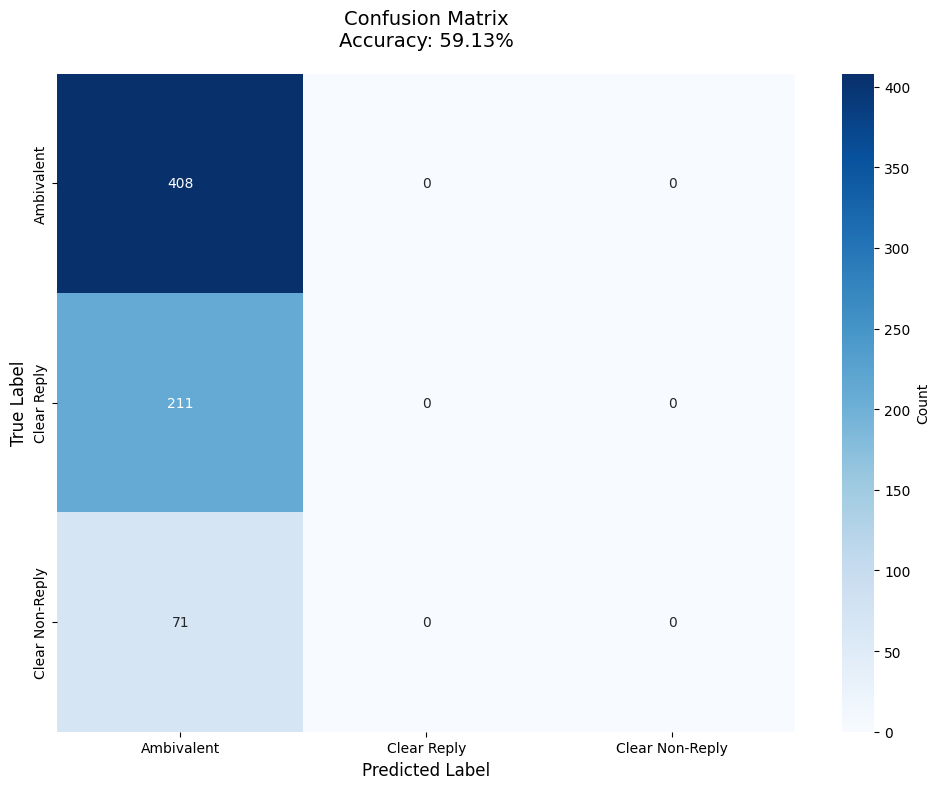

In [266]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


def evaluate(model, X_q_test, X_a_test, y_test, batch_size=32):
    model.eval()
    test_dataset = TensorDataset(X_q_test, X_a_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    correct = 0
    total = 0
    
    # Store all predictions and true labels
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for X_q_batch, X_a_batch, y_batch in test_loader:
            log_probs = model(X_q_batch, X_a_batch)
            _, predicted = torch.max(log_probs, 1)
            
            # Store predictions and labels
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    
    # Create confusion matrix
    cm = confusion_matrix(y_true=all_labels, y_pred=all_predictions)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    
    # Class labels (adjust these to your actual class names)
    class_names = ['Ambivalent', 'Clear Reply', 'Clear Non-Reply']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    
    plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.2f}%', fontsize=14, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return accuracy, cm

accuracy, confusion_mat = evaluate(trained_model, X_q_test, X_a_test, y_test)
